In [4]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

from utils import *

In [5]:
#%matplotlib inline
auto_plot_style()

In [6]:
def sipm_positions():
    size   = 6
    gap    = 0.2
    n      = 10
    offset = n * (size + gap) / 2.
    xy     = (np.arange(n) + 0.5) * (size + gap) - offset
    return (xy, *np.meshgrid(xy, xy, indexing="ij"))

def extent():
    size   = 6
    gap    = 0.2
    n      = 10
    offset = n * (size + gap) / 2.
    return (-offset, offset) * 2

def npmap(f, it):
    return np.array(list(map(f, it)))

def wire_pos():
    n = 12
    p =  5
    return np.arange(12) * p - (n - 1) * p/2

def wire_limits():
    p = wire_pos()
    return np.append(p - 2.5, p[-1] + 2.5)


empty_df = pd.DataFrame(dict(counts=0), index=pd.Index(np.arange(100), name="sensor_id"))
def image(df):
    df = df.set_index("sensor_id")
    df = pd.concat([df, empty_df])
    df = df.groupby(level=0).sum()
    return pd.DataFrame(dict(image=[df.sort_index().counts.values.reshape(1, 10,10)]))

def rotate(xy, a):
    c = np.cos(a)
    s = np.sin(a)
    m = np.array([ [c, -s]
                 , [s,  c] ])
    return m.dot(xy)
    
def gate_pos(df, a=np.pi/4):
    xrot, yrot = rotate(df.loc[:, list("xy")].values.T, np.pi/4)
    xi         = np.clip(np.digitize(xrot, wire_limits()) - 1, 0, 12)
    wx         = wire_pos()[xi]
    dx         = xrot - wx
    a          = np.arctan(dx/(df.z - (-5.20)))
    dx         = a/(np.pi/2) * 2.5
    x, y       = rotate(np.stack([wx+dx, yrot], axis=1).T, -np.pi/4)
    return pd.DataFrame(dict(event=df.event, x0=x, y0=y, z0=df.z))

def read_file(filename):
    sensor_hits = pd.read_hdf(filename, "/MC/sensor_hits").loc[lambda df: df.sensor_id < 100]
    sources     = pd.read_hdf(filename, "/MC/sources").drop(columns="e n".split())
    sources     = gate_pos(sources)
    sources     = sources.set_index("event")
    sources.insert(3, "r0", (sources.x0**2 + sources.y0**2)**0.5)
    sensor_hits = sensor_hits.groupby("event sensor_id".split()).count().rename(columns=dict(time="counts")).reset_index()
    images = (sensor_hits.groupby("event")
                         .apply(image, include_groups=False)
                         .reset_index(level=1, drop=True))
    out = pd.concat([sources, images], axis=1)
    out = out[~out.image.isna()]
    return out

def barycenter(df, sipm_x, sipm_y, nsipms):
    img = df.image.values[0][0]
    tot = img.sum().sum()
    xb  = (sipm_x * img).sum().sum() / tot
    yb  = (sipm_y * img).sum().sum() / tot
    return pd.Series(dict(x=xb, y=yb))

In [15]:
path      = Path("/home/gonzalo/data/COLINA/mc/colina/dsipms_15mm/")
filenames = sorted(path.glob("*.h5"))
len(filenames)

10

In [83]:
testdf = read_file(filenames[0])
testdf

,x0,y0,z0,r0,image
event,,,,,
0,30.772733,10.749722,-5.177589,32.596282,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0,..."
1,18.970594,-2.348197,-5.199509,19.115373,"[[[0, 0, 1, 1, 0, 1, 0, 0, 0, 0], [1, 0, 0, 3,..."
2,-6.163524,-11.086080,-5.183395,12.684250,"[[[2, 3, 0, 0, 1, 0, 0, 1, 0, 0], [4, 2, 3, 2,..."
3,-17.723786,24.687642,-5.199817,30.390990,"[[[0, 0, 0, 2, 2, 3, 5, 1, 6, 5], [0, 0, 1, 3,..."
4,-26.320919,-12.968632,-5.196890,29.342396,"[[[3, 5, 4, 6, 4, 4, 2, 1, 0, 0], [9, 6, 9, 6,..."
...,...,...,...,...,...
29995,-17.804012,-19.942175,-5.171360,26.733372,"[[[3, 4, 1, 3, 0, 1, 1, 3, 0, 0], [5, 4, 8, 6,..."
29996,1.366462,-12.482809,-5.194952,12.557377,"[[[1, 1, 1, 2, 3, 3, 2, 1, 0, 0], [2, 1, 5, 4,..."
29997,-6.254362,15.110490,-5.197443,16.353714,"[[[0, 0, 0, 2, 2, 0, 1, 4, 1, 4], [0, 2, 3, 1,..."


In [84]:
rbins  = np.linspace(  0, 32, 81)
xybins = np.linspace(-32, 32, 81)
drbins = np.linspace(  0, 32, 81)

In [85]:
nsipms    = 10
sipm_pos  = sipm_positions()[0]
sipm_x    = sipm_positions()[1]
sipm_y    = sipm_positions()[2]
extents   = extent()
ticks     = np.arange(-30, 31, 10)

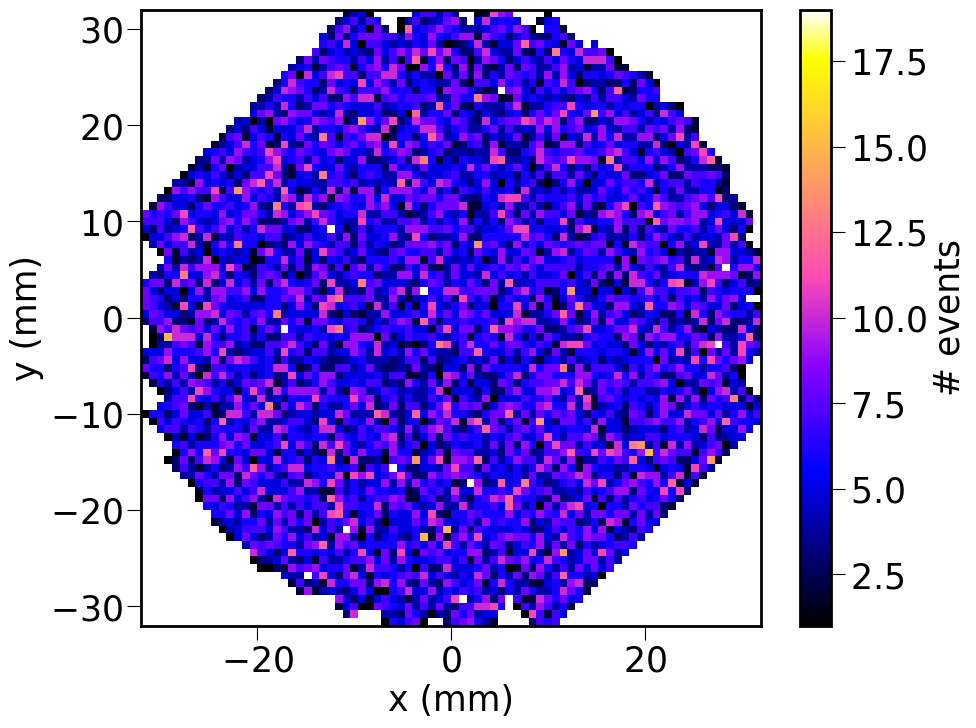

In [86]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

# Barycenter

In [88]:
df = testdf
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y, nsipms)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [89]:
reco_bb

,x,y,x0,y0,z0,r0,dx,dy,dr
event,,,,,,,,,
0,12.733846,6.406667,30.772733,10.749722,-5.177589,32.596282,-18.038887,-4.343056,18.554341
1,10.223922,-2.516471,18.970594,-2.348197,-5.199509,19.115373,-8.746672,-0.168273,8.748291
2,-0.106897,-7.963793,-6.163524,-11.086080,-5.183395,12.684250,6.056628,3.122286,6.814060
3,-7.390179,10.351786,-17.723786,24.687642,-5.199817,30.390990,10.333607,-14.335856,17.672018
4,-12.187255,-4.801961,-26.320919,-12.968632,-5.196890,29.342396,14.133664,8.166671,16.323449
...,...,...,...,...,...,...,...,...,...
29995,-9.332461,-8.878010,-17.804012,-19.942175,-5.171360,26.733372,8.471551,11.064165,13.934953
29996,-0.590970,-6.003010,1.366462,-12.482809,-5.194952,12.557377,-1.957432,6.479798,6.768998
29997,-3.334848,7.303788,-6.254362,15.110490,-5.197443,16.353714,2.919513,-7.806702,8.334756


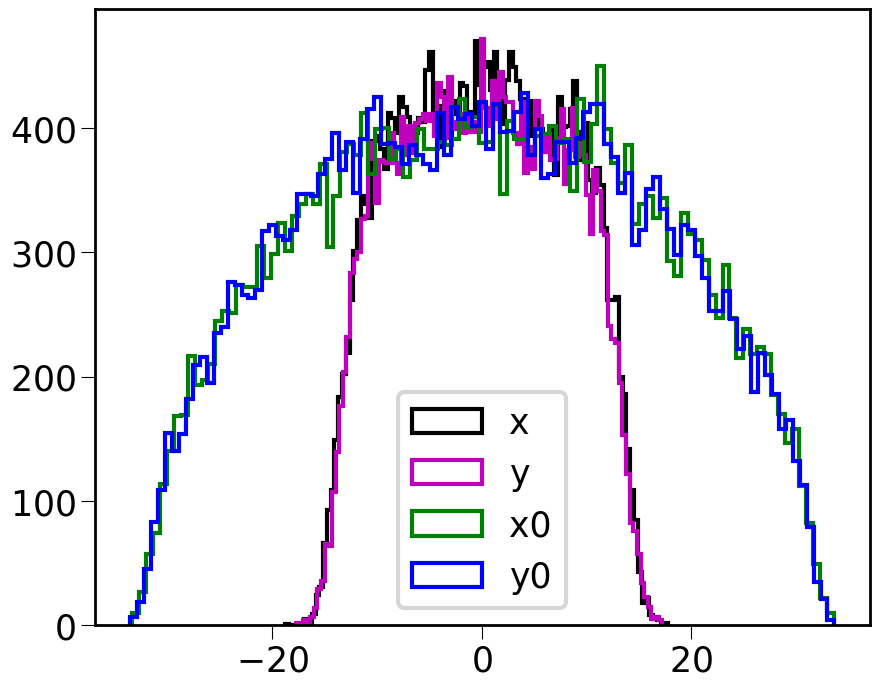

In [90]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

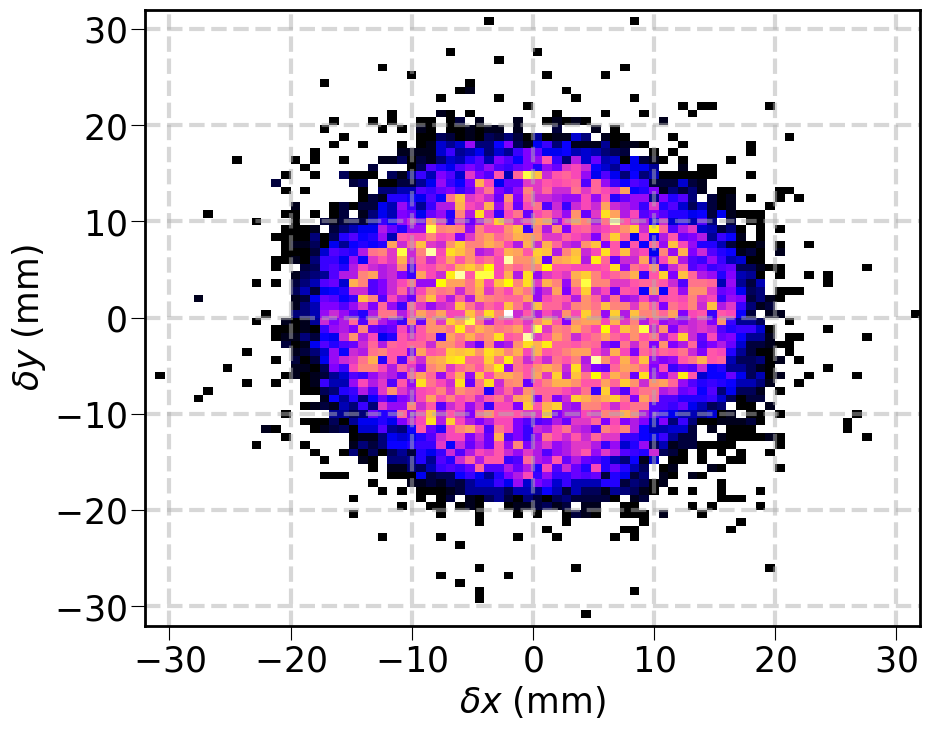

In [91]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

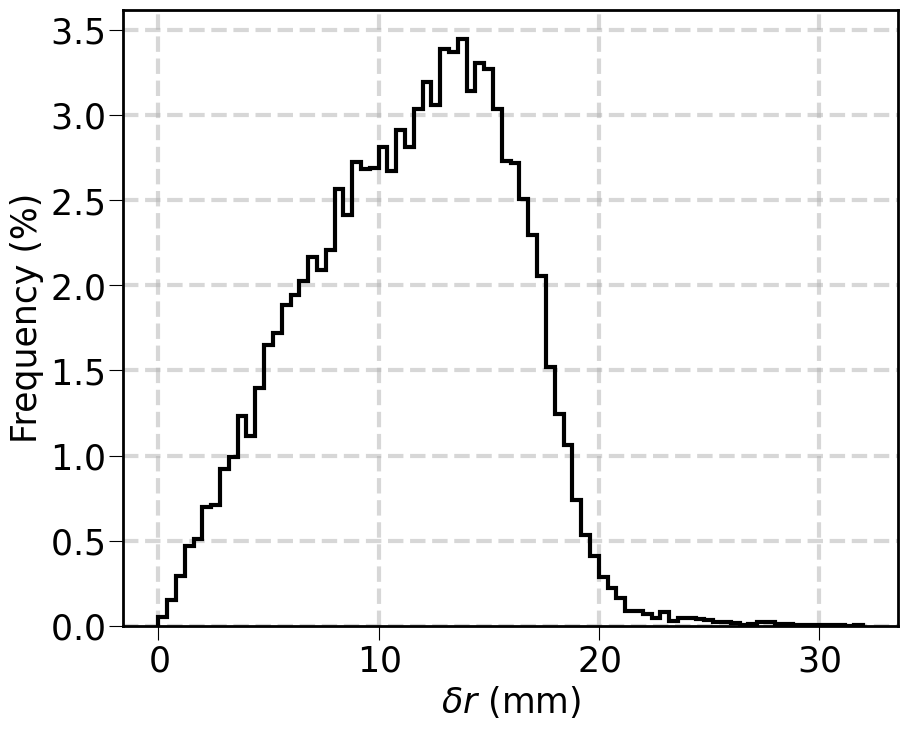

In [92]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

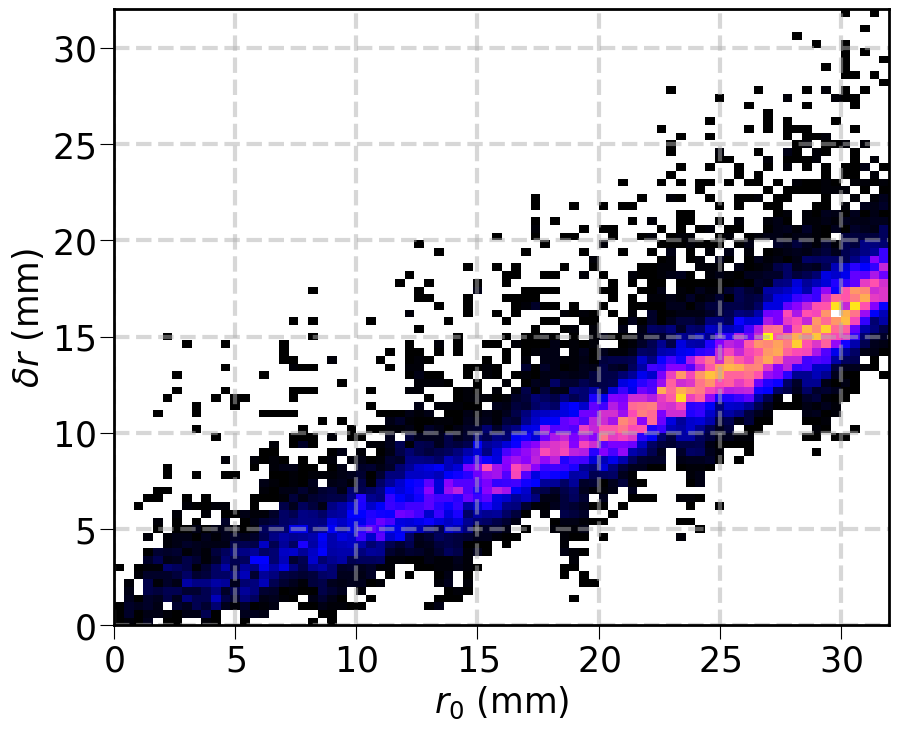

In [93]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

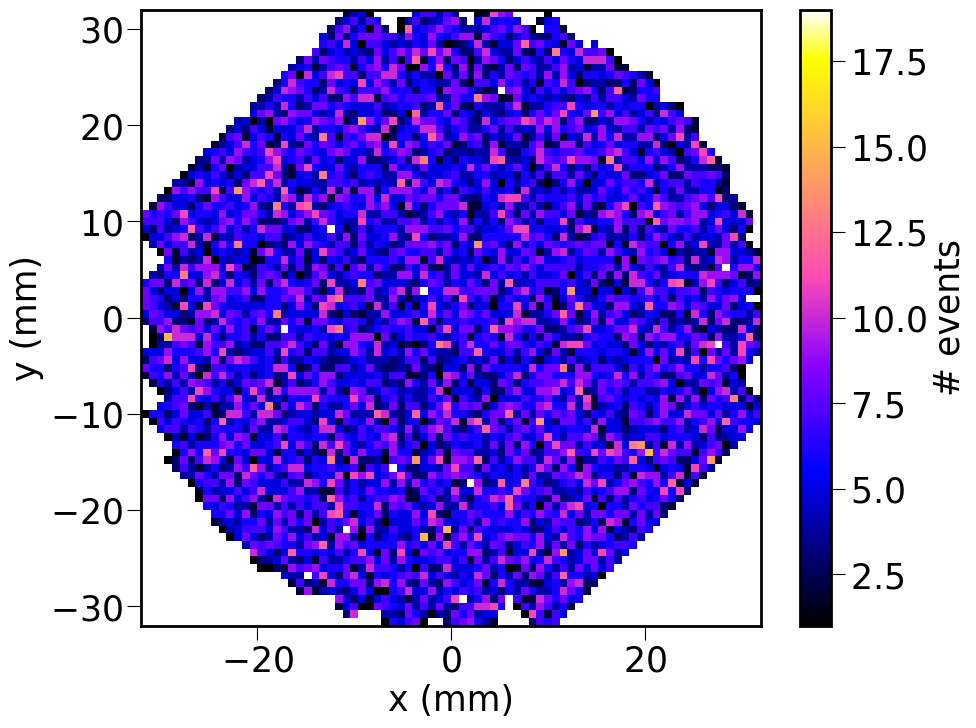

In [94]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

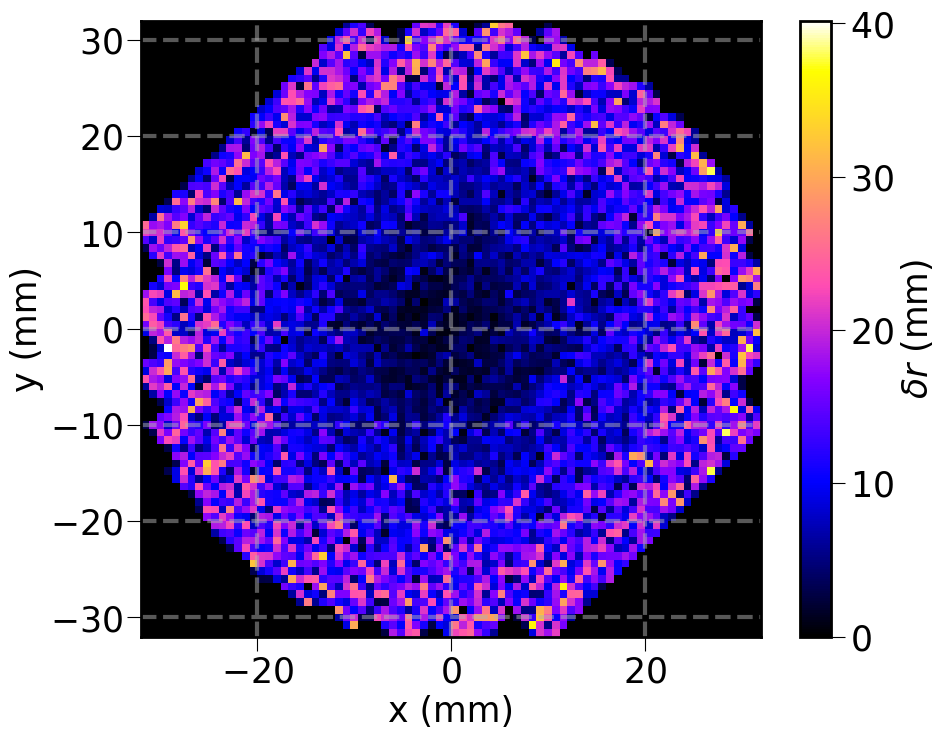

In [95]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

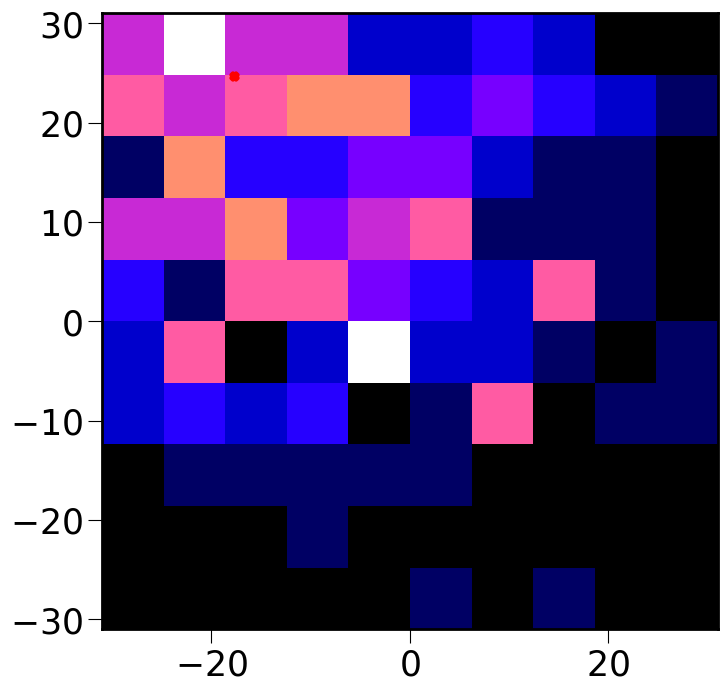

In [108]:
row = df.iloc[3]
img = row.image[0]
x   = row.x0
y   = row.y0
plt.imshow(img.T, origin="lower", extent=extent());
plt.scatter([x], [y], s=20, marker="X", color="r");

# NN

In [96]:
import torch
import torch.nn as nn
import torch.optim as optim

In [97]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [109]:
train     = pd.concat([read_file(filename) for filename in filenames[:5]])
test      = pd.concat([read_file(filename) for filename in filenames[5:]])
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [110]:
model     = Linear(nsipms, nsipms)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [111]:
epochs = 50
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 50 of 50 | 7.03 s/item | ETA 0.1 min | Ellapsed 5.7 min


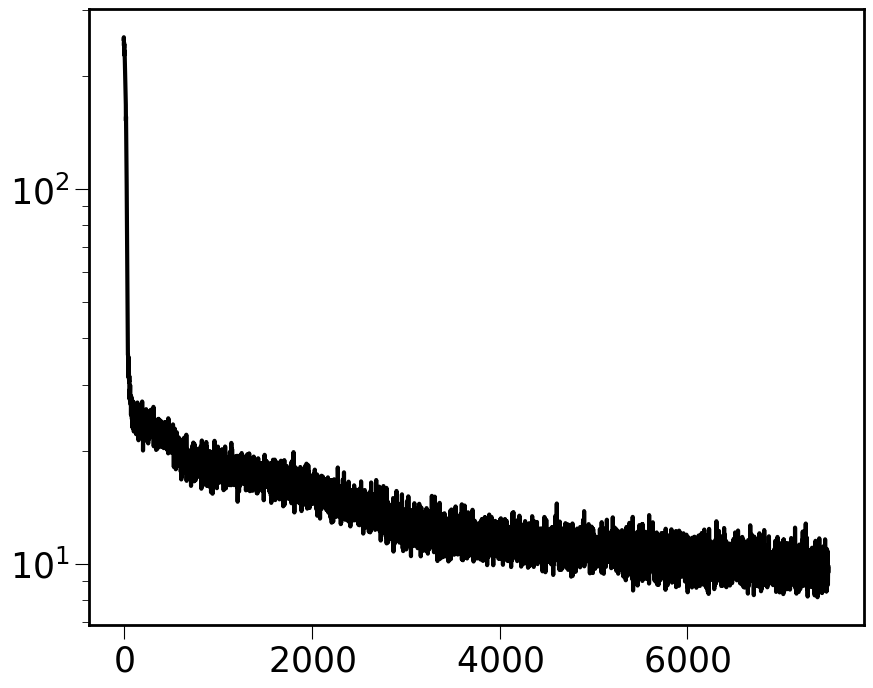

In [122]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [123]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

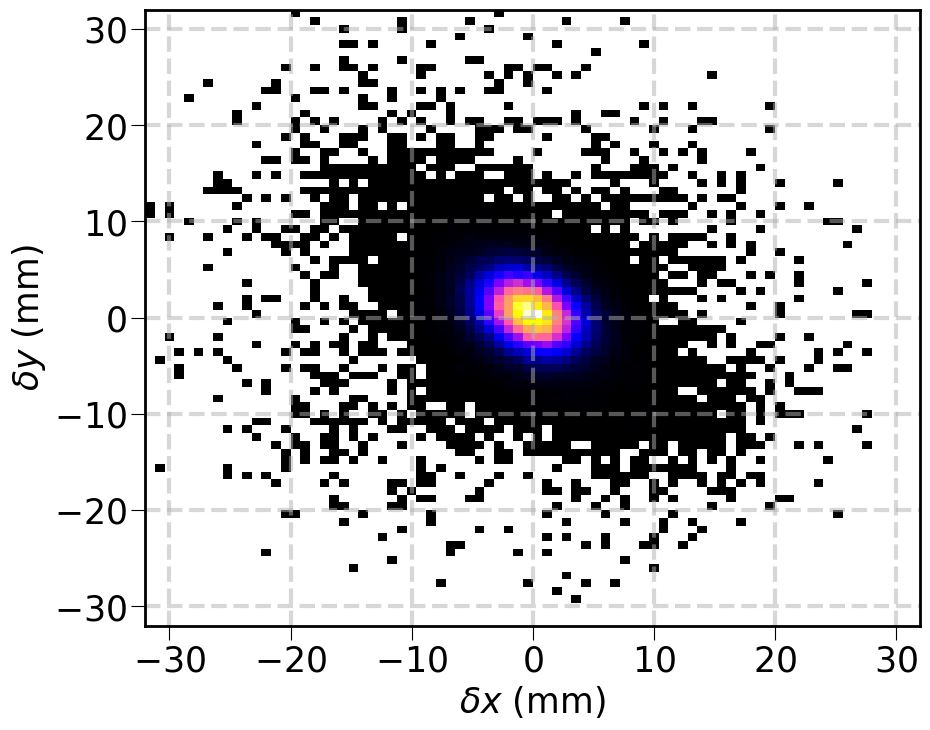

In [124]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

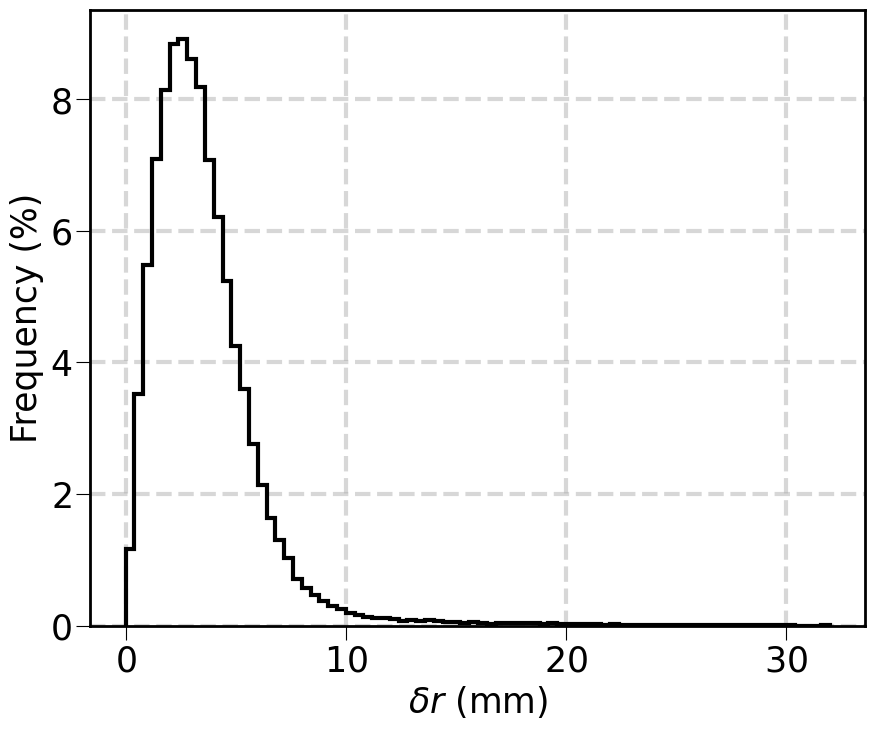

In [125]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

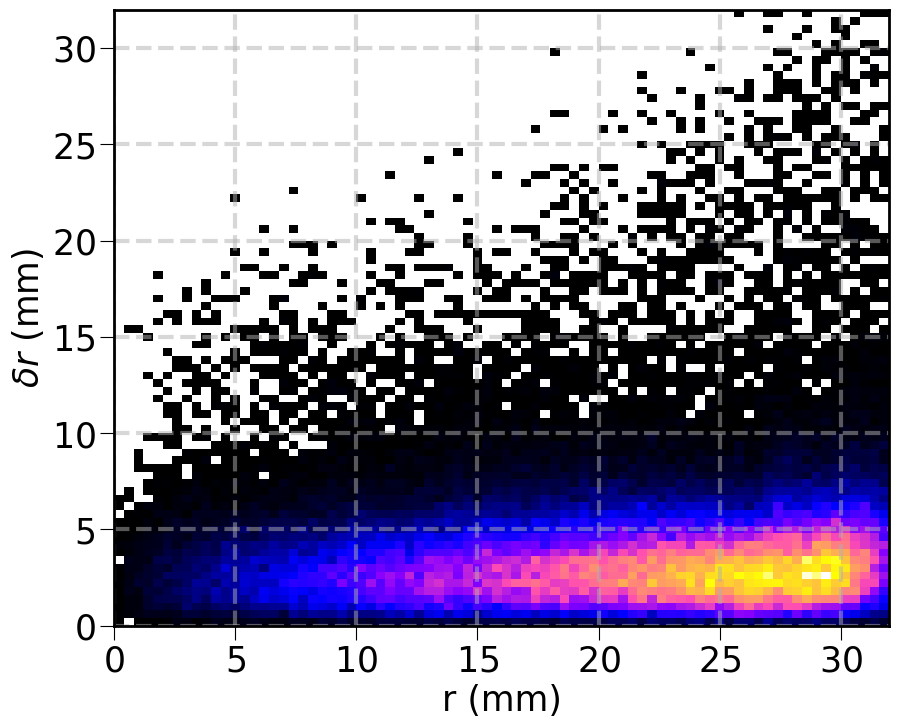

In [126]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

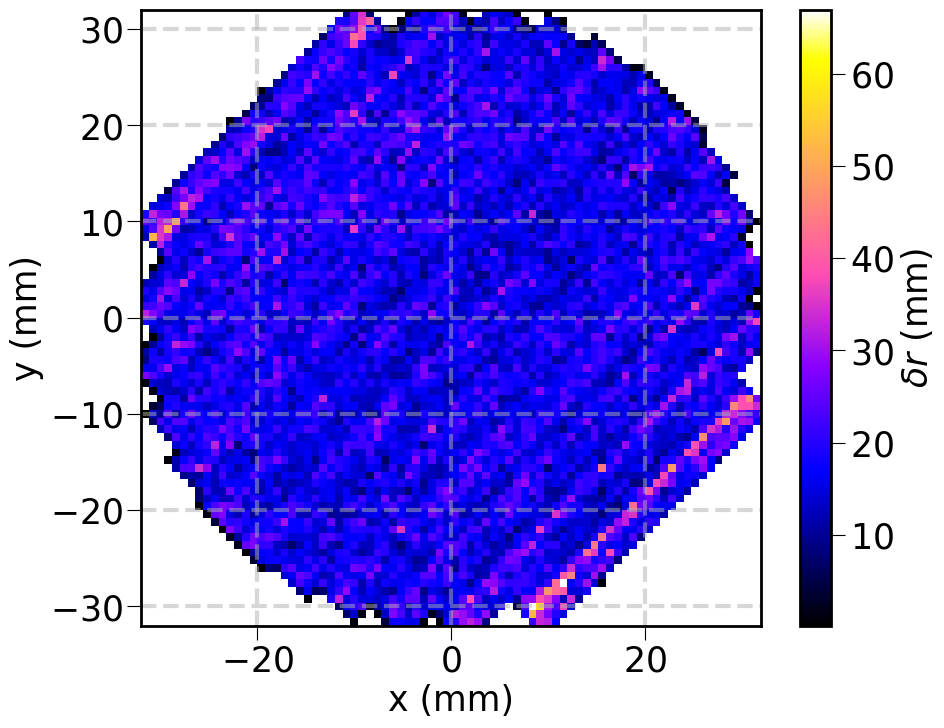

In [127]:
plt.hist2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr/evt_per_bin, cmin=1e-3)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

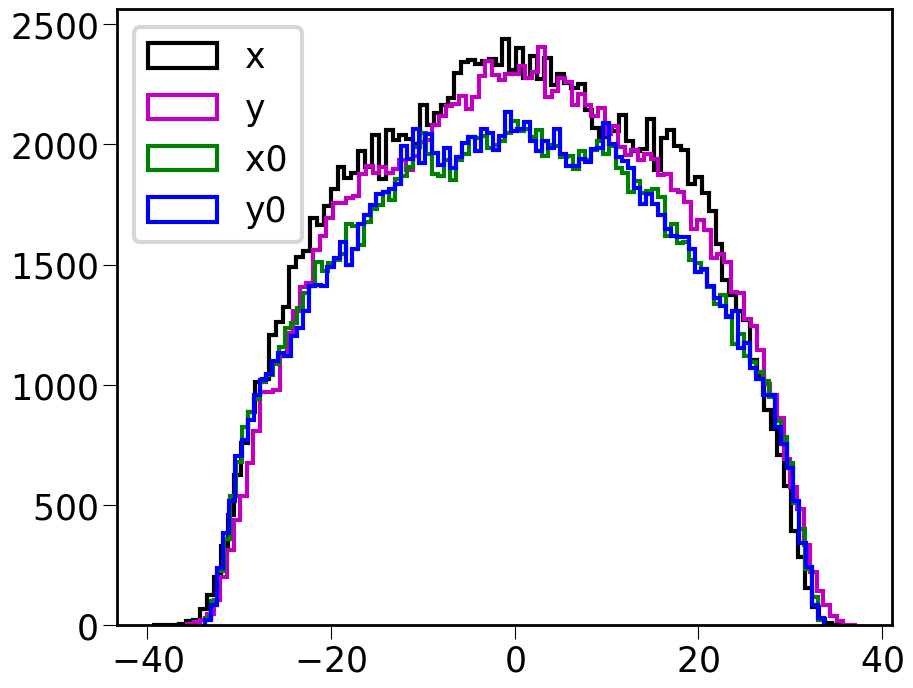

In [128]:
plt.hist(reco_nn.x , 101, histtype="step", label="x");
plt.hist(reco_nn.y , 101, histtype="step", label="y");
plt.hist(reco_nn.x0, 101, histtype="step", label="x0");
plt.hist(reco_nn.y0, 101, histtype="step", label="y0");
plt.legend()

In [29]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
0,-1.767633,-14.932930,15.037184,-1.669243,-15.023207,0.098390,-0.090277,0.133531
1,-8.556936,-4.352665,9.600357,-7.980200,-4.031803,0.576736,0.320862,0.659983
2,-13.062822,4.363532,13.772353,-12.714380,4.200193,0.348442,-0.163339,0.384827
3,-4.928335,9.280847,10.508217,-4.637556,9.363155,0.290780,0.082307,0.302204
4,-10.989004,-7.359574,13.225790,-10.721936,-7.674867,0.267068,-0.315293,0.413201
...,...,...,...,...,...,...,...,...
999995,-15.349733,3.599069,15.766027,-14.753126,3.747703,0.596608,0.148634,0.614844
999996,6.447406,-2.305508,6.847219,6.441365,-2.082120,-0.006041,0.223388,0.223470
999997,3.198898,-0.875269,3.316481,3.067275,-1.073316,-0.131623,-0.198047,0.237797
999998,-11.244277,4.309097,12.041681,-10.677136,4.387750,0.567140,0.078654,0.572568


In [30]:
reco = pd.DataFrame.join( reco_bb
                        , reco_nn.drop(columns="x0 y0 r0".split())
                        , lsuffix="_bb"
                        , rsuffix="_nn")

In [31]:
reco

,x0,y0,r0,x_bb,y_bb,dx_bb,dy_bb,dr_bb,x_nn,y_nn,dx_nn,dy_nn,dr_nn
0,-1.767633,-14.932930,15.037184,-2.315265,-7.372419,-0.547633,7.560511,7.580318,-1.669243,-15.023207,0.098390,-0.090277,0.133531
1,-8.556936,-4.352665,9.600357,-5.372259,-3.826263,3.184677,0.526402,3.227889,-7.980200,-4.031803,0.576736,0.320862,0.659983
2,-13.062822,4.363532,13.772353,-8.043192,3.919336,5.019629,-0.444195,5.039245,-12.714380,4.200193,0.348442,-0.163339,0.384827
3,-4.928335,9.280847,10.508217,-4.067968,7.115298,0.860368,-2.165549,2.330201,-4.637556,9.363155,0.290780,0.082307,0.302204
4,-10.989004,-7.359574,13.225790,-7.081354,-5.764275,3.907649,1.595299,4.220747,-10.721936,-7.674867,0.267068,-0.315293,0.413201
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,-15.349733,3.599069,15.766027,-7.897409,2.121148,7.452324,-1.477921,7.597459,-14.753126,3.747703,0.596608,0.148634,0.614844
999996,6.447406,-2.305508,6.847219,5.227853,-2.951380,-1.219553,-0.645873,1.380022,6.441365,-2.082120,-0.006041,0.223388,0.223470
999997,3.198898,-0.875269,3.316481,1.552987,0.254656,-1.645911,1.129925,1.996436,3.067275,-1.073316,-0.131623,-0.198047,0.237797
999998,-11.244277,4.309097,12.041681,-7.633721,3.905039,3.610556,-0.404058,3.633094,-10.677136,4.387750,0.567140,0.078654,0.572568


In [32]:
reco.to_hdf(output, key="/data", complib="zlib", complevel=4)

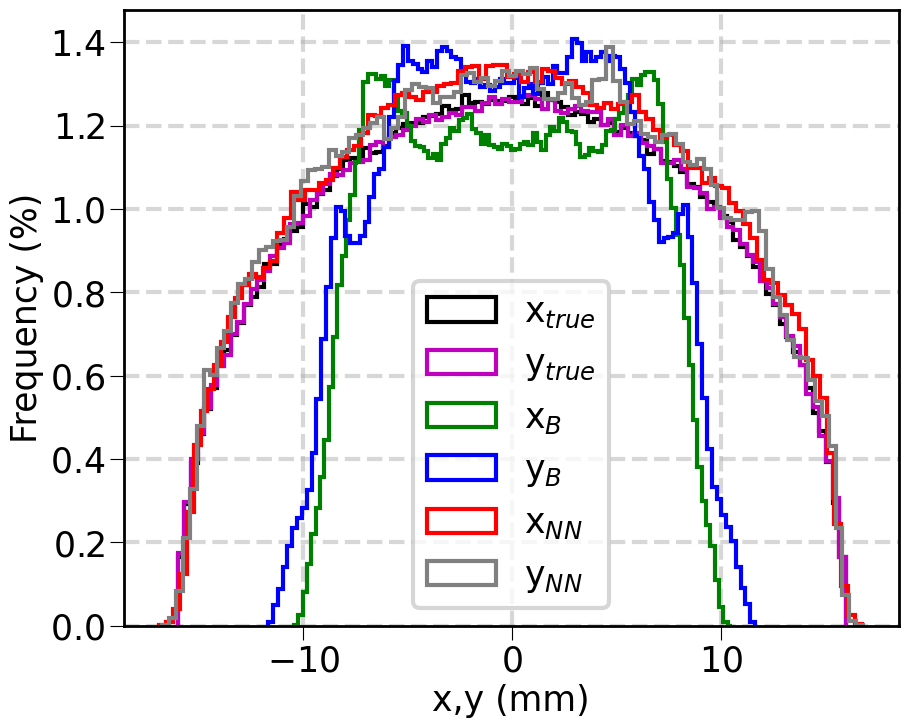

In [33]:
normhist(reco.x0  , 101, histtype="step", label="x$_{true}$");
normhist(reco.y0  , 101, histtype="step", label="y$_{true}$");
normhist(reco.x_bb, 101, histtype="step", label="x$_{B}$");
normhist(reco.y_bb, 101, histtype="step", label="y$_{B}$");
normhist(reco.x_nn, 101, histtype="step", label="x$_{NN}$");
normhist(reco.y_nn, 101, histtype="step", label="y$_{NN}$");
plt.legend()
plt.xlabel("x,y (mm)")
plt.ylabel("Frequency (%)")
plt.grid()